# Random Forest Air Quality Alarm Prediction with Visualizations

This notebook trains a Random Forest classifier to predict air quality alarms based on sensor data.

**Sensors:**
- PM2.5 and PM10 (particulate matter)
- Temperature
- Pressure
- Humidity

**Goal:** Predict whether an alarm should be triggered (0 = No alarm, 1 = Alarm)

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score
)

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load and Explore Dataset

In [ ]:
# Load dataset
# Note: You need to merge individual CSV files (PM2.5.csv, PM10.csv, Temperature.csv, Humidity.csv, Gas.csv, Carbon Monoxide.csv)
# or create a combined dataset file for this notebook to work properly
dataset_path = '../dataset/combined_data.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (1406, 7)

Columns: ['created_at', 'pm2_5', 'pm10', 'temp', 'trysnia', 'lageshtira', 'alarm_status']

First few rows:


,created_at,pm2_5,pm10,temp,trysnia,lageshtira,alarm_status
0,2019-09-24T22:36:25+02:00,6.4,18.0,23.2,99833,91.87,0
1,2019-09-24T22:37:19+02:00,6.5,19.0,23.2,99835,91.87,0
2,2019-09-24T22:38:13+02:00,6.5,19.0,23.2,99831,91.78,0
3,2019-09-24T22:39:07+02:00,6.4,19.4,25.4,99837,91.78,0
4,2019-09-24T22:40:01+02:00,6.4,19.7,24.0,99832,91.78,0
5,2019-09-24T22:40:55+02:00,6.4,19.6,23.6,99836,91.64,0
6,2019-09-24T22:41:49+02:00,6.4,19.5,23.5,99838,91.64,0
7,2019-09-24T22:42:43+02:00,6.5,19.9,23.5,99844,91.64,0
8,2019-09-24T22:43:37+02:00,6.5,20.0,23.5,99842,91.64,0
9,2019-09-24T22:44:31+02:00,6.5,19.5,23.4,99833,91.64,0


In [8]:
# Dataset information
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1406 entries, 0 to 1405
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   created_at    1406 non-null   object 
 1   pm2_5         1406 non-null   float64
 2   pm10          1406 non-null   float64
 3   temp          1406 non-null   float64
 4   trysnia       1406 non-null   int64  
 5   lageshtira    1406 non-null   float64
 6   alarm_status  1406 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 77.0+ KB
None

Missing values:
created_at      0
pm2_5           0
pm10            0
temp            0
trysnia         0
lageshtira      0
alarm_status    0
dtype: int64

Basic statistics:


,pm2_5,pm10,temp,trysnia,lageshtira,alarm_status
count,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000
mean,8.822688,17.824680,22.442390,100256.989331,81.830341,0.396871
std,4.318699,7.248395,1.483627,215.182314,8.944349,0.489423
min,4.300000,6.800000,20.300000,99824.000000,62.200000,0.000000
25%,5.400000,11.300000,21.100000,100207.500000,82.200000,0.000000
50%,6.300000,16.200000,22.400000,100300.000000,83.500000,0.000000
75%,13.100000,21.600000,23.200000,100406.000000,88.457500,1.000000
max,22.800000,37.500000,31.400000,100537.000000,91.870000,1.000000


## 3. Data Visualization - Exploratory Data Analysis

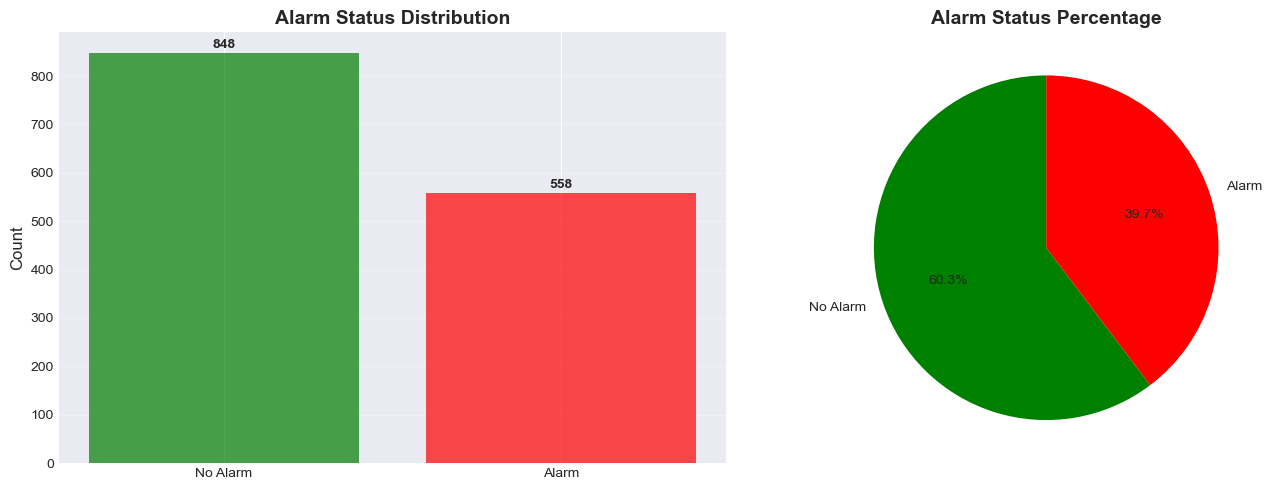

Total samples: 1406
No alarm (0): 848 (60.3%)
Alarm (1): 558 (39.7%)


In [9]:
# Distribution of alarm status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
alarm_counts = df['alarm_status'].value_counts()
axes[0].bar(['No Alarm', 'Alarm'], alarm_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Alarm Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(alarm_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(alarm_counts.values, labels=['No Alarm', 'Alarm'], 
            autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Alarm Status Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total samples: {len(df)}")
print(f"No alarm (0): {alarm_counts[0]} ({alarm_counts[0]/len(df)*100:.1f}%)")
print(f"Alarm (1): {alarm_counts[1]} ({alarm_counts[1]/len(df)*100:.1f}%)")

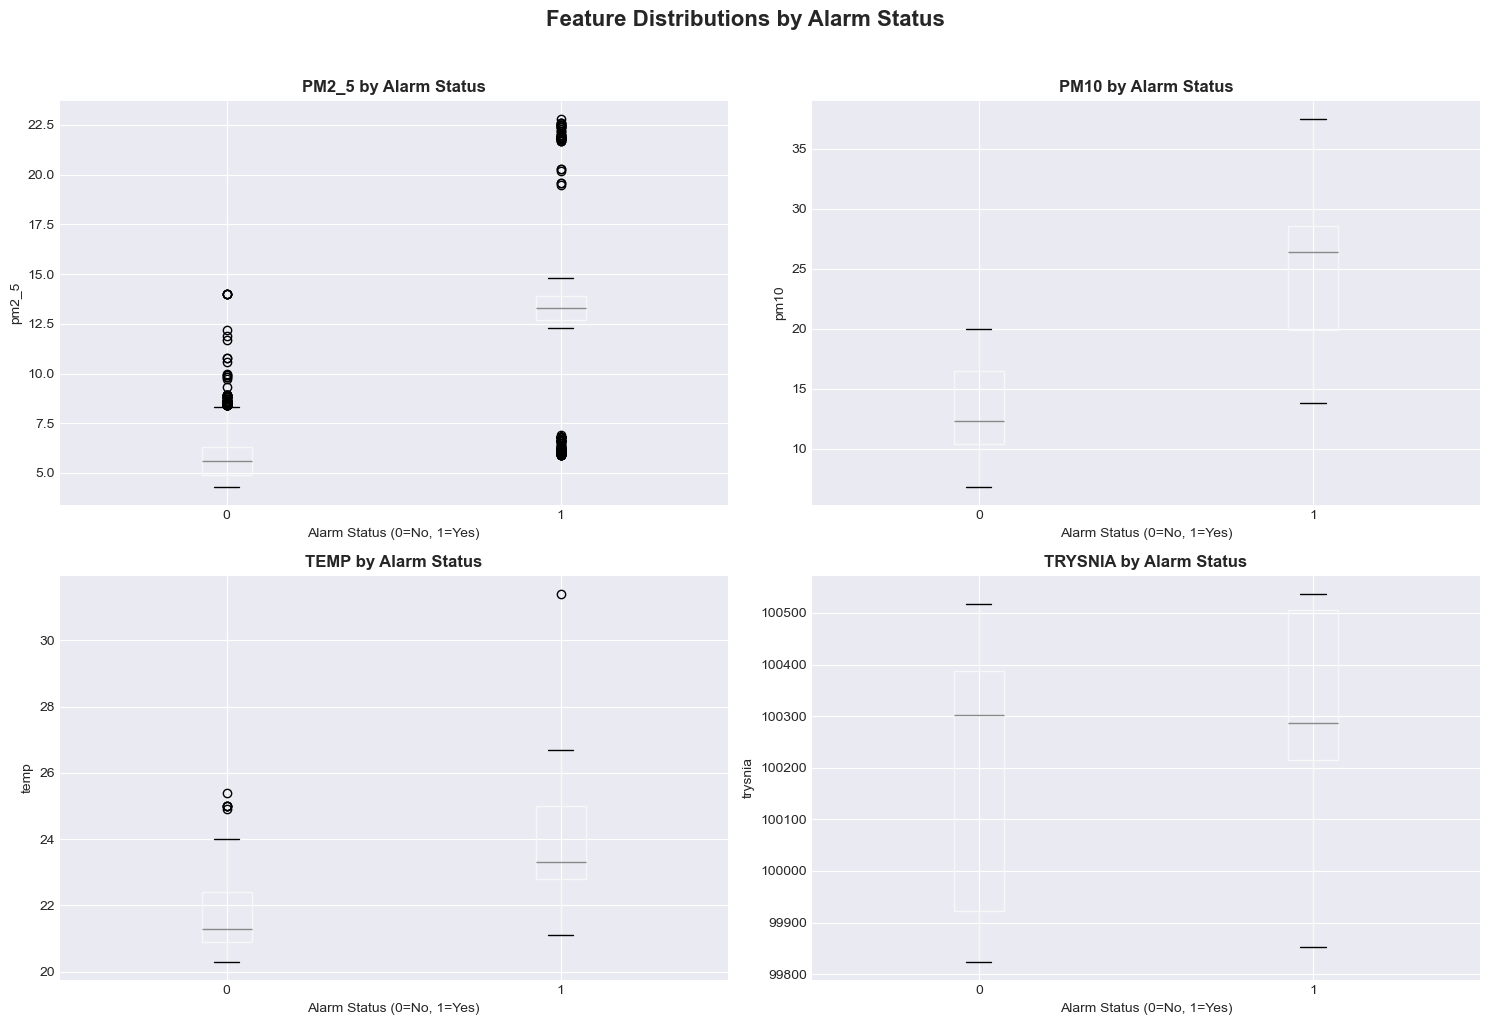

In [ ]:
# Feature distributions by alarm status
# Features: PM2.5, PM10, Temperature, Humidity, Gas, Carbon Monoxide
features = ['pm2_5', 'pm10', 'temp', 'humidity', 'gas', 'co']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    # Box plot
    df.boxplot(column=feature, by='alarm_status', ax=axes[idx])
    axes[idx].set_title(f'{feature.upper()} by Alarm Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Alarm Status (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    
plt.suptitle('Feature Distributions by Alarm Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

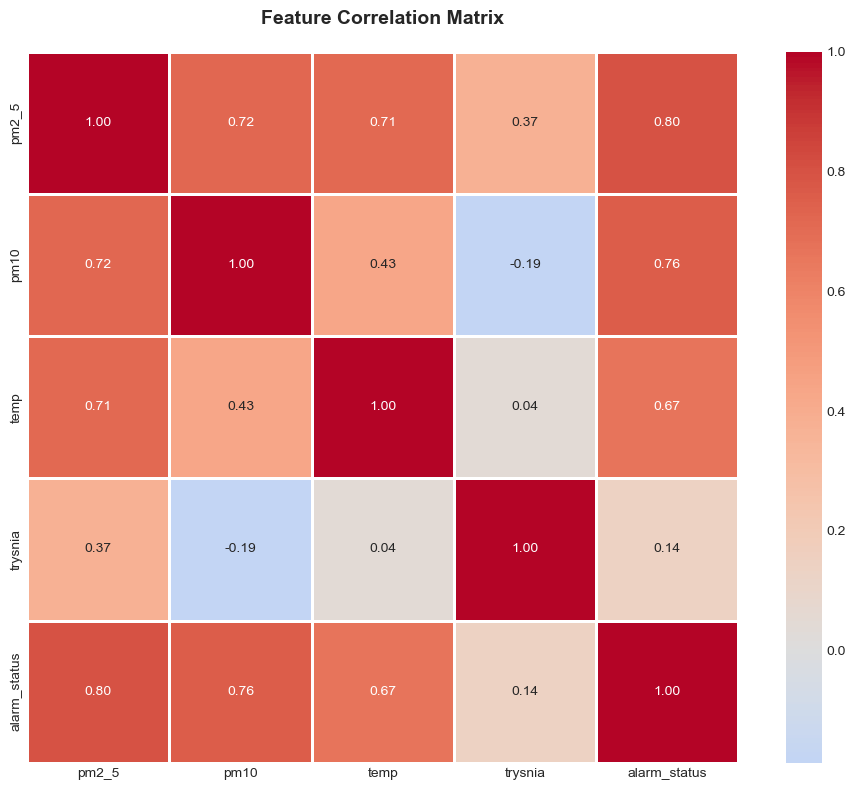

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[features + ['alarm_status']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

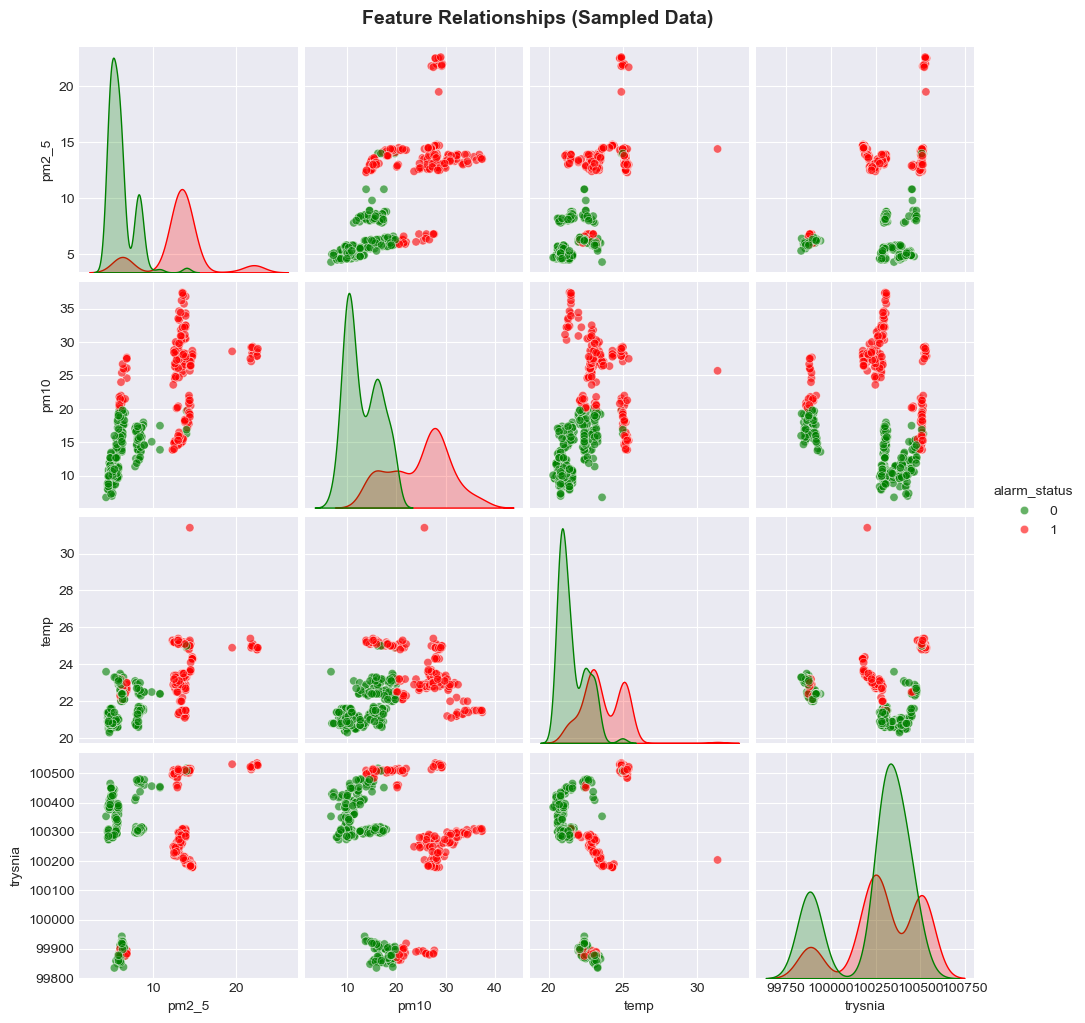

In [12]:
# Pair plot for feature relationships
import warnings
warnings.filterwarnings('ignore')

# Sample data if too large
df_sample = df.sample(min(500, len(df)), random_state=42)

sns.pairplot(df_sample[features + ['alarm_status']], 
             hue='alarm_status', 
             palette={0: 'green', 1: 'red'},
             diag_kind='kde',
             plot_kws={'alpha': 0.6})
plt.suptitle('Feature Relationships (Sampled Data)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

In [ ]:
# Prepare features and target
# Features: PM2.5, PM10, Temperature, Humidity, Gas, Carbon Monoxide
features = ['pm2_5', 'pm10', 'temp', 'humidity', 'gas', 'co']
X = df[features].values
y = df['alarm_status'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution: {np.bincount(y)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data preprocessing complete")

Features shape: (1406, 4)
Target shape: (1406,)

Target distribution: [848 558]

Training set: (1054, 4)
Test set: (352, 4)

✓ Data preprocessing complete


## 5. Model Training with Hyperparameter Tuning

In [14]:
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Starting hyperparameter tuning...")
print(f"Total combinations to try: {np.prod([len(v) for v in param_grid.values()])}")

# Create base model
rf_base = RandomForestClassifier(random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    rf_base, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2
)

# Fit the model
grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("="*60)

Starting hyperparameter tuning...
Total combinations to try: 108
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GRID SEARCH RESULTS
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.9962


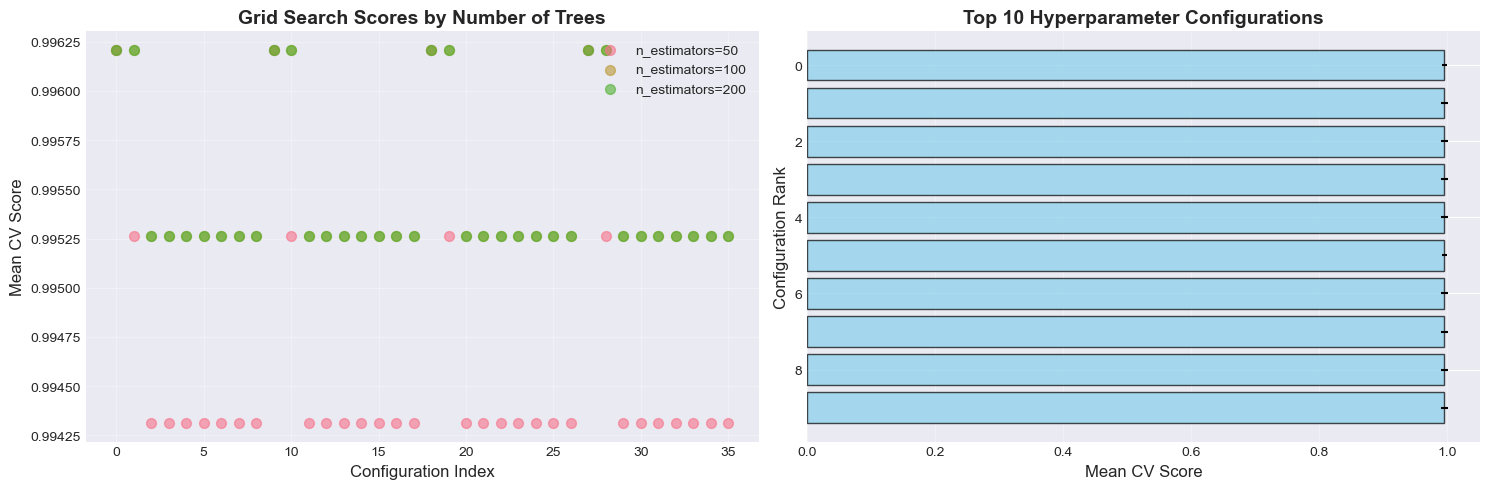

In [15]:
# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)

# Plot mean test scores for different n_estimators
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Group by n_estimators
for n_est in param_grid['n_estimators']:
    mask = results_df['param_n_estimators'] == n_est
    subset = results_df[mask]
    axes[0].scatter(range(len(subset)), subset['mean_test_score'], 
                   label=f'n_estimators={n_est}', alpha=0.6, s=50)

axes[0].set_xlabel('Configuration Index', fontsize=12)
axes[0].set_ylabel('Mean CV Score', fontsize=12)
axes[0].set_title('Grid Search Scores by Number of Trees', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 10 configurations
top_10 = results_df.nlargest(10, 'mean_test_score')[['mean_test_score', 'std_test_score']]
axes[1].barh(range(10), top_10['mean_test_score'], xerr=top_10['std_test_score'], 
            alpha=0.7, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Mean CV Score', fontsize=12)
axes[1].set_ylabel('Configuration Rank', fontsize=12)
axes[1].set_title('Top 10 Hyperparameter Configurations', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Evaluation

In [16]:
# Get best model
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*60)
print("MODEL PERFORMANCE ON TEST SET")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Alarm', 'Alarm']))
print("="*60)

MODEL PERFORMANCE ON TEST SET
Accuracy: 1.0000
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

    No Alarm       1.00      1.00      1.00       212
       Alarm       1.00      1.00      1.00       140

    accuracy                           1.00       352
   macro avg       1.00      1.00      1.00       352
weighted avg       1.00      1.00      1.00       352



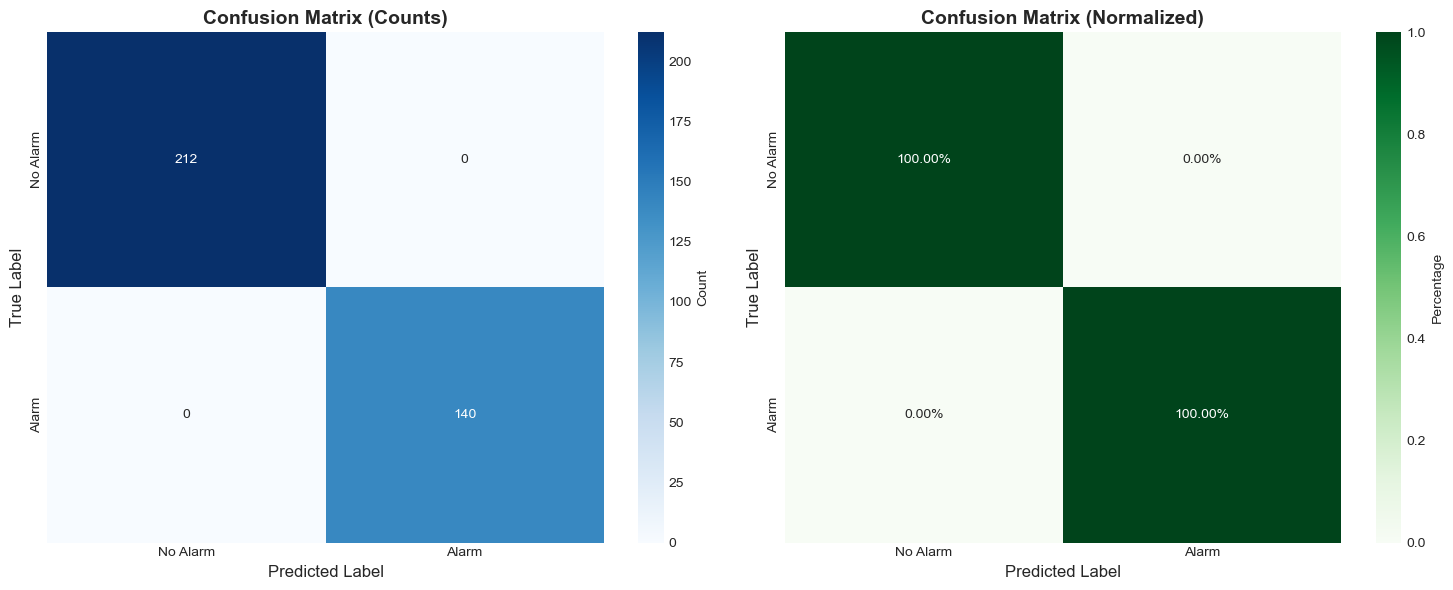


True Negatives: 212
False Positives: 0
False Negatives: 0
True Positives: 140


In [17]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix - counts
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Alarm', 'Alarm'],
            yticklabels=['No Alarm', 'Alarm'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Confusion matrix - normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['No Alarm', 'Alarm'],
            yticklabels=['No Alarm', 'Alarm'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# Print confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

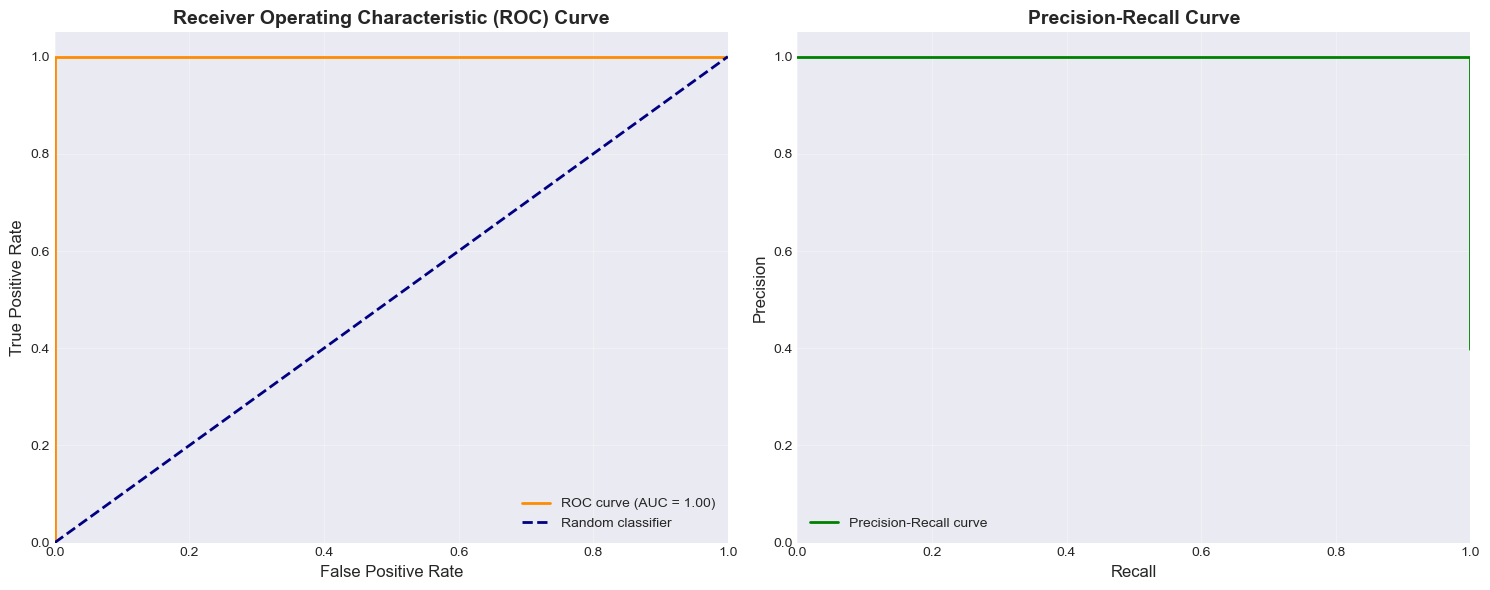

ROC AUC Score: 1.0000


In [18]:
# ROC Curve and Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

axes[1].plot(recall, precision, color='green', lw=2, label='Precision-Recall curve')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

## 7. Feature Importance Analysis

In [19]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)
print(f"\nTotal importance: {feature_importance['importance'].sum():.4f}")

Feature Importance:
   feature  importance
0    pm2_5    0.504189
1     pm10    0.342569
2     temp    0.107807
3  trysnia    0.045435

Total importance: 1.0000


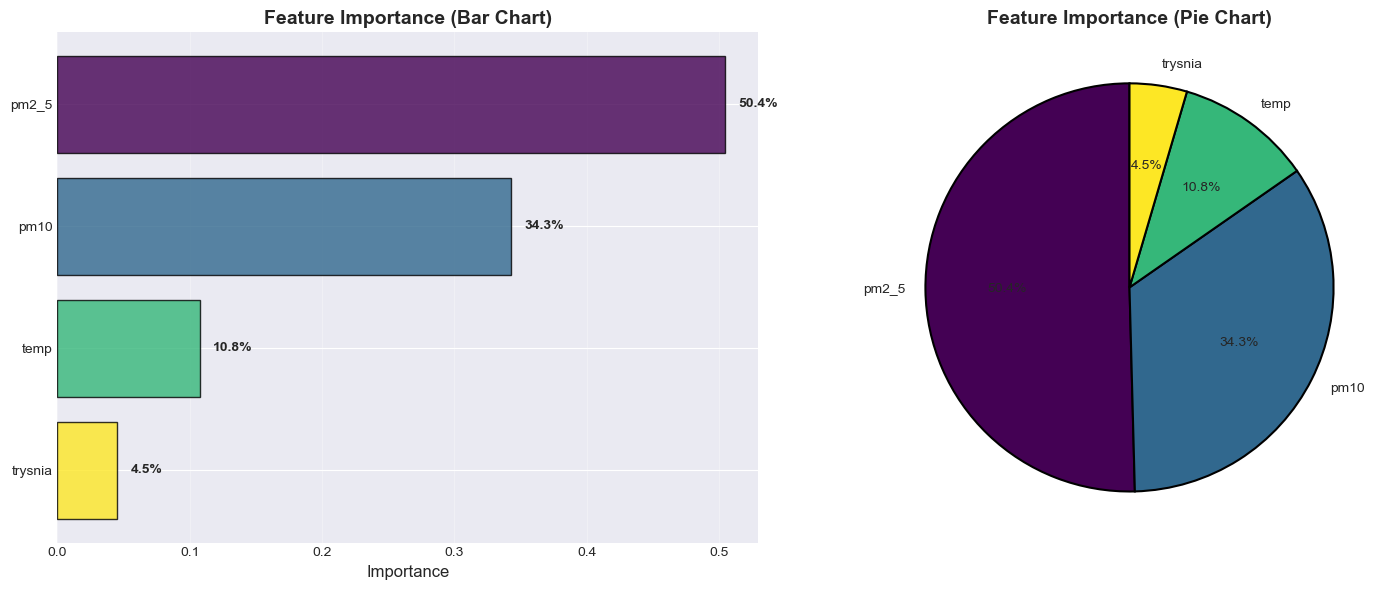

In [20]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
axes[0].barh(feature_importance['feature'], feature_importance['importance'], 
            color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Feature Importance (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    axes[0].text(row['importance'] + 0.01, i, f"{row['importance']:.1%}", 
                va='center', fontweight='bold')

# Pie chart
axes[1].pie(feature_importance['importance'], labels=feature_importance['feature'],
           autopct='%1.1f%%', colors=colors, startangle=90, 
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Feature Importance (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Learning Curves

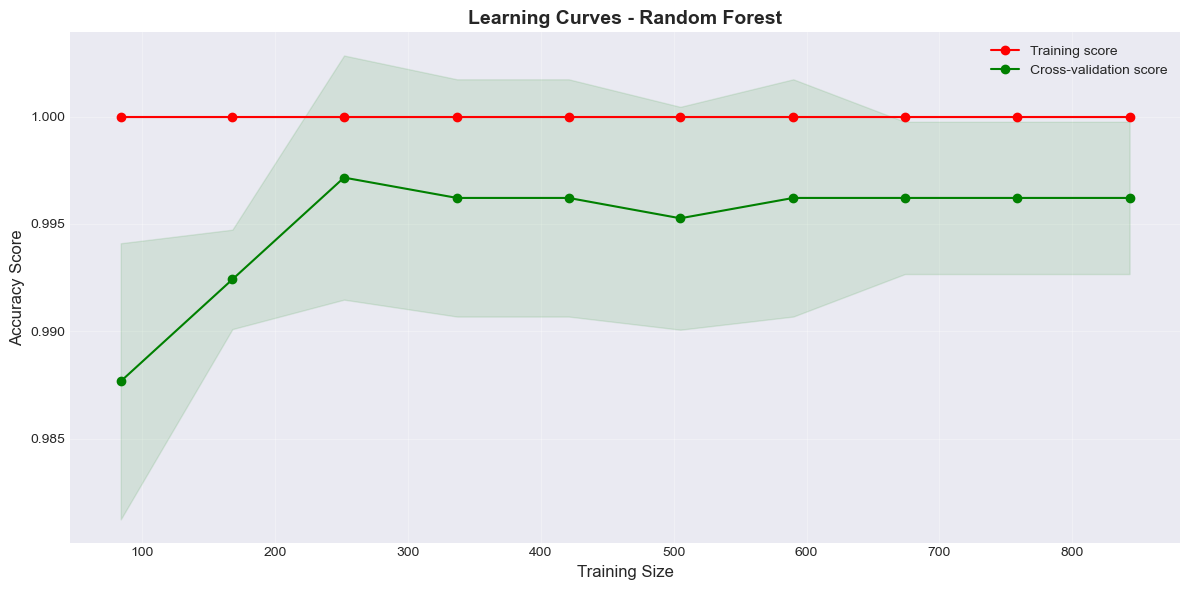

Final training score: 1.0000 ± 0.0000
Final validation score: 0.9962 ± 0.0035


In [21]:
# Learning curve - how model performance changes with training size
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, n_jobs=-1, scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='g')

plt.xlabel('Training Size', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Learning Curves - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training score: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Final validation score: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")

## 9. Cross-Validation Scores

10-Fold Cross-Validation Results:
Scores: [0.98113208 1.         1.         1.         0.99047619 1.
 0.99047619 1.         1.         1.        ]

Mean Accuracy: 0.9962
Standard Deviation: 0.0063
Min: 0.9811
Max: 1.0000


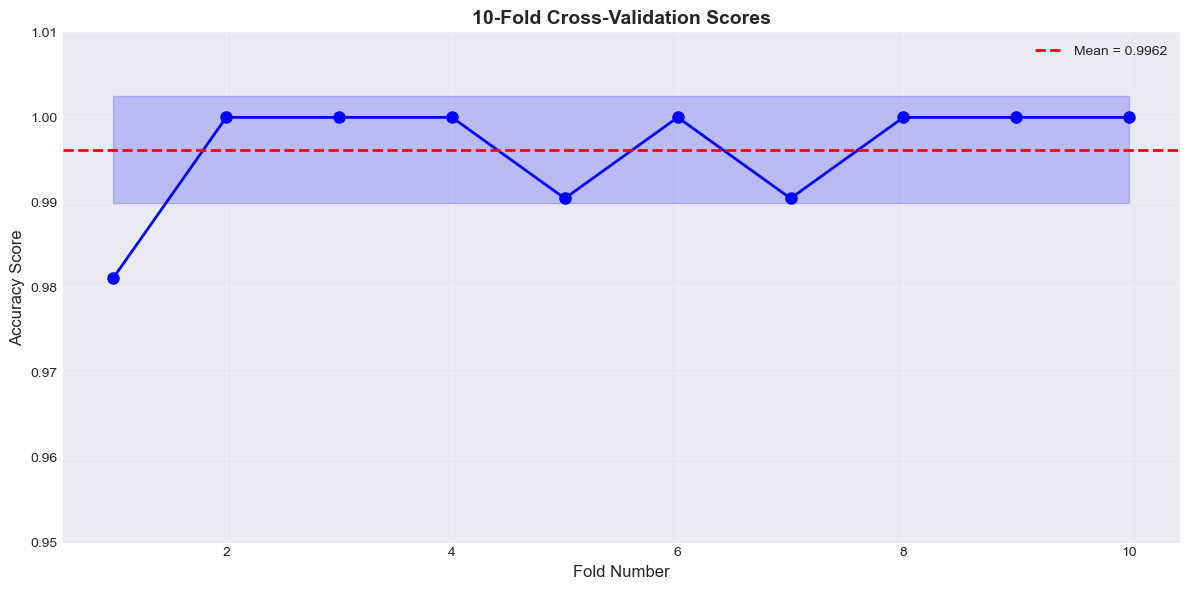

In [22]:
# Perform cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation Results:")
print(f"Scores: {cv_scores}")
print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Min: {cv_scores.min():.4f}")
print(f"Max: {cv_scores.max():.4f}")

# Visualize CV scores
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), cv_scores, 'o-', markersize=8, linewidth=2, color='blue')
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', 
           label=f'Mean = {cv_scores.mean():.4f}', linewidth=2)
plt.fill_between(range(1, 11), cv_scores.mean() - cv_scores.std(), 
                cv_scores.mean() + cv_scores.std(), alpha=0.2, color='blue')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('10-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim([0.95, 1.01])
plt.tight_layout()
plt.show()

## 10. Model Interpretation - Decision Paths

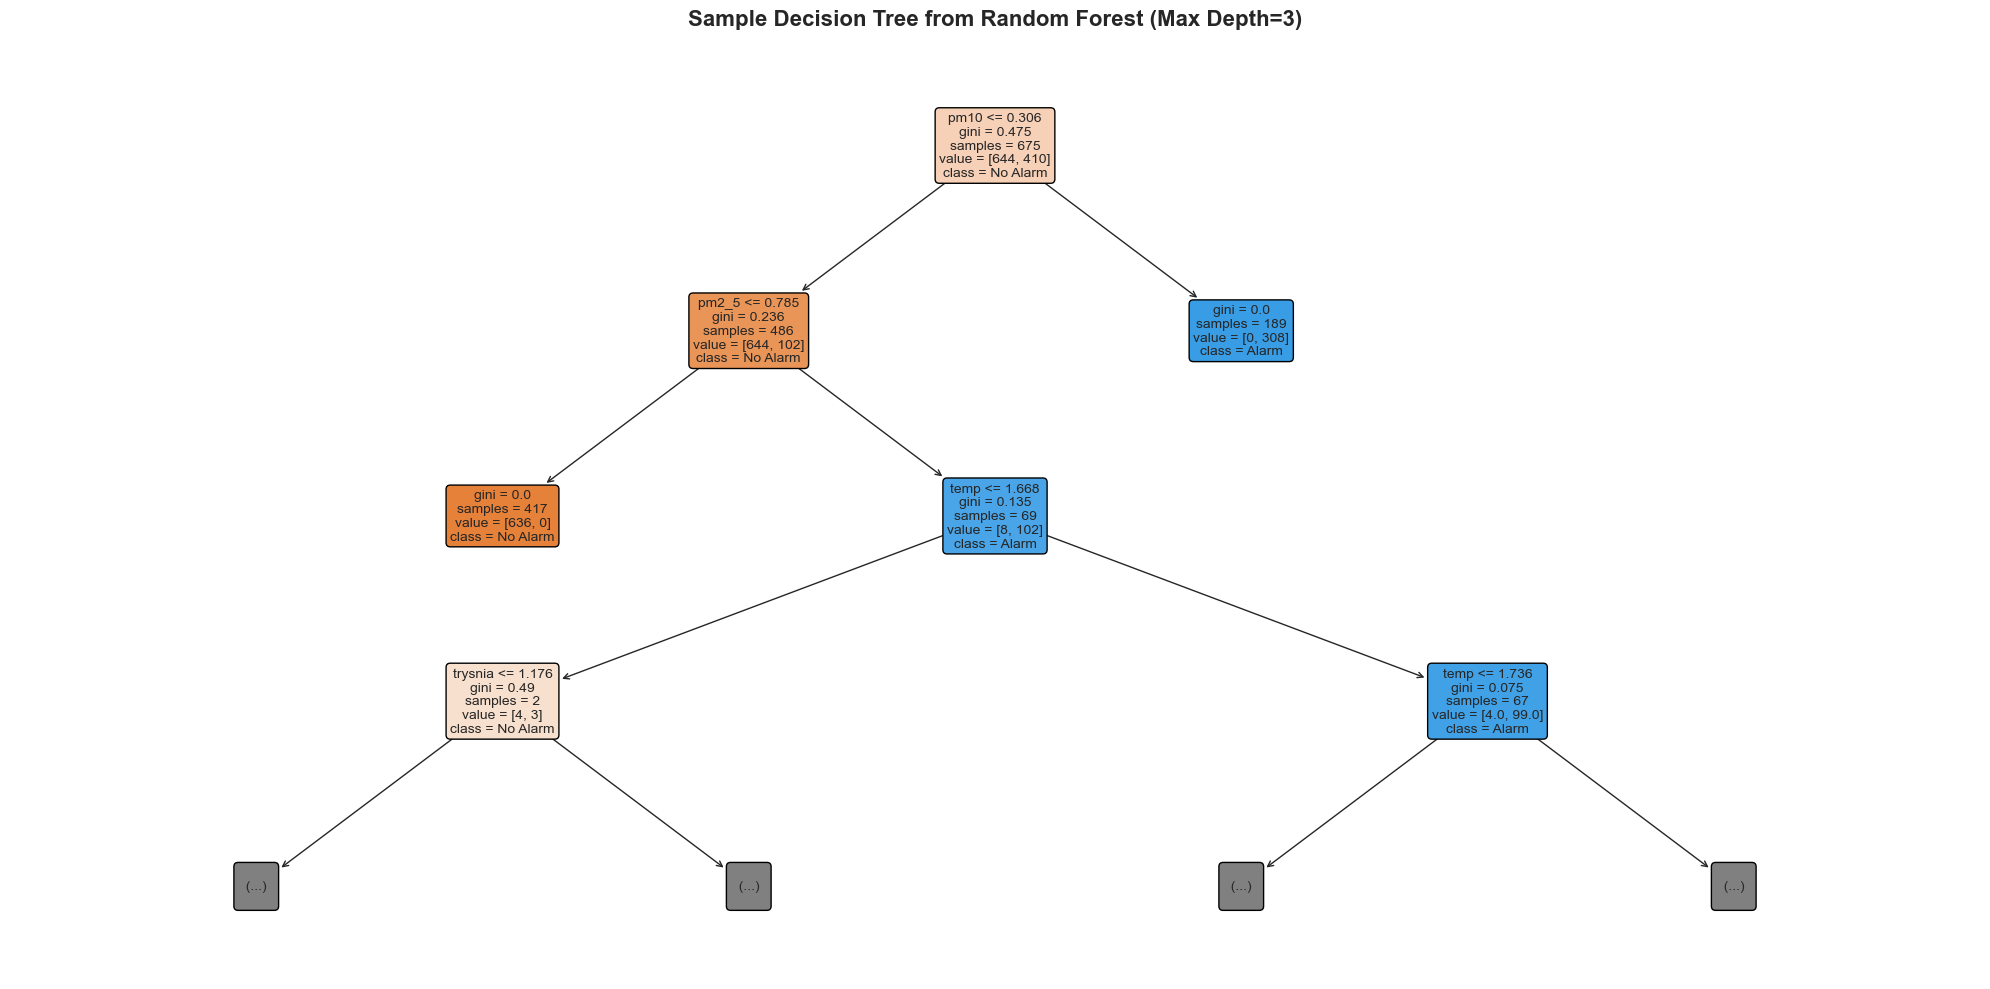

Total number of trees in forest: 50


In [23]:
# Visualize a single decision tree from the forest
from sklearn.tree import plot_tree

# Plot first tree (simplified)
plt.figure(figsize=(20, 10))
plot_tree(best_model.estimators_[0], 
         feature_names=features,
         class_names=['No Alarm', 'Alarm'],
         filled=True, 
         rounded=True,
         max_depth=3,  # Limit depth for readability
         fontsize=10)
plt.title('Sample Decision Tree from Random Forest (Max Depth=3)', 
         fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"Total number of trees in forest: {len(best_model.estimators_)}")

## 11. Prediction Examples

In [24]:
# Test with sample data
test_samples = [
    {'pm2_5': 10, 'pm10': 20, 'temp': 22, 'trysnia': 1013},  # Normal
    {'pm2_5': 50, 'pm10': 80, 'temp': 28, 'trysnia': 1010},  # High pollution
    {'pm2_5': 100, 'pm10': 150, 'temp': 32, 'trysnia': 1005},  # Very high
    {'pm2_5': 5, 'pm10': 15, 'temp': 18, 'trysnia': 1020},  # Very clean
]

print("="*80)
print("PREDICTION EXAMPLES")
print("="*80)

for i, sample in enumerate(test_samples, 1):
    # Prepare input
    input_data = np.array([[sample['pm2_5'], sample['pm10'], 
                           sample['temp'], sample['trysnia']]])
    input_scaled = scaler.transform(input_data)
    
    # Predict
    prediction = best_model.predict(input_scaled)[0]
    probability = best_model.predict_proba(input_scaled)[0]
    
    print(f"\nSample {i}:")
    print(f"  PM2.5: {sample['pm2_5']} μg/m³")
    print(f"  PM10: {sample['pm10']} μg/m³")
    print(f"  Temperature: {sample['temp']}°C")
    print(f"  Pressure: {sample['trysnia']} hPa")
    print(f"  → Prediction: {'⚠️ ALARM' if prediction == 1 else '✓ NO ALARM'}")
    print(f"  → Confidence: {max(probability):.1%}")
    print(f"  → Probabilities: No Alarm={probability[0]:.1%}, Alarm={probability[1]:.1%}")

print("\n" + "="*80)

PREDICTION EXAMPLES

Sample 1:
  PM2.5: 10 μg/m³
  PM10: 20 μg/m³
  Temperature: 22°C
  Pressure: 1013 hPa
  → Prediction: ✓ NO ALARM
  → Confidence: 86.0%
  → Probabilities: No Alarm=86.0%, Alarm=14.0%

Sample 2:
  PM2.5: 50 μg/m³
  PM10: 80 μg/m³
  Temperature: 28°C
  Pressure: 1010 hPa
  → Prediction: ⚠️ ALARM
  → Confidence: 98.0%
  → Probabilities: No Alarm=2.0%, Alarm=98.0%

Sample 3:
  PM2.5: 100 μg/m³
  PM10: 150 μg/m³
  Temperature: 32°C
  Pressure: 1005 hPa
  → Prediction: ⚠️ ALARM
  → Confidence: 98.0%
  → Probabilities: No Alarm=2.0%, Alarm=98.0%

Sample 4:
  PM2.5: 5 μg/m³
  PM10: 15 μg/m³
  Temperature: 18°C
  Pressure: 1020 hPa
  → Prediction: ✓ NO ALARM
  → Confidence: 100.0%
  → Probabilities: No Alarm=100.0%, Alarm=0.0%



## 12. Save Model and Scaler

In [25]:
# Create models directory
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save model
model_path = os.path.join(models_dir, 'random_forest_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Model saved to: {model_path}")

# Save scaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to: {scaler_path}")

# Save feature names
feature_path = os.path.join(models_dir, 'feature_names.pkl')
with open(feature_path, 'wb') as f:
    pickle.dump(features, f)
print(f"✓ Feature names saved to: {feature_path}")

print("\n" + "="*60)
print("All models and scalers saved successfully!")
print("You can now use these files with the ML inference server.")
print("="*60)

✓ Model saved to: ../models\random_forest_model.pkl
✓ Scaler saved to: ../models\scaler.pkl
✓ Feature names saved to: ../models\feature_names.pkl

All models and scalers saved successfully!
You can now use these files with the ML inference server.


## 13. Summary Report

In [26]:
# Generate comprehensive summary
summary = f"""
{'='*80}
RANDOM FOREST AIR QUALITY ALARM PREDICTION - SUMMARY REPORT
{'='*80}

Dataset Information:
  - Total samples: {len(df)}
  - Features: {', '.join(features)}
  - Target: alarm_status (0=No Alarm, 1=Alarm)
  - Training samples: {len(X_train)}
  - Test samples: {len(X_test)}

Best Model Configuration:
  - Number of trees: {best_model.n_estimators}
  - Max depth: {best_model.max_depth}
  - Min samples split: {best_model.min_samples_split}
  - Min samples leaf: {best_model.min_samples_leaf}

Performance Metrics:
  - Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
  - F1 Score: {f1:.4f}
  - ROC AUC: {roc_auc:.4f}
  - Cross-validation Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

Confusion Matrix:
  - True Negatives: {tn}
  - False Positives: {fp}
  - False Negatives: {fn}
  - True Positives: {tp}

Feature Importance (Top to Bottom):
"""

for idx, row in feature_importance.iterrows():
    summary += f"  - {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)\n"

summary += f"""
Model Files Saved:
  - Model: {model_path}
  - Scaler: {scaler_path}
  - Features: {feature_path}

Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(summary)

# Save summary to file
summary_path = os.path.join(models_dir, 'model_summary.txt')
with open(summary_path, 'w') as f:
    f.write(summary)
print(f"\n✓ Summary report saved to: {summary_path}")


RANDOM FOREST AIR QUALITY ALARM PREDICTION - SUMMARY REPORT

Dataset Information:
  - Total samples: 1406
  - Features: pm2_5, pm10, temp, trysnia
  - Target: alarm_status (0=No Alarm, 1=Alarm)
  - Training samples: 1054
  - Test samples: 352

Best Model Configuration:
  - Number of trees: 50
  - Max depth: None
  - Min samples split: 2
  - Min samples leaf: 1

Performance Metrics:
  - Test Accuracy: 1.0000 (100.00%)
  - F1 Score: 1.0000
  - ROC AUC: 1.0000
  - Cross-validation Score: 0.9962 ± 0.0063

Confusion Matrix:
  - True Negatives: 212
  - False Positives: 0
  - False Negatives: 0
  - True Positives: 140

Feature Importance (Top to Bottom):
  - pm2_5: 0.5042 (50.42%)
  - pm10: 0.3426 (34.26%)
  - temp: 0.1078 (10.78%)
  - trysnia: 0.0454 (4.54%)

Model Files Saved:
  - Model: ../models\random_forest_model.pkl
  - Scaler: ../models\scaler.pkl
  - Features: ../models\feature_names.pkl

Date: 2026-02-04 15:24:30


✓ Summary report saved to: ../models\model_summary.txt


## 🎉 Training Complete!

Your Random Forest model has been successfully trained and evaluated with comprehensive visualizations.

### Next Steps:
1. Start the ML inference server: `python src/ml_inference_server.py`
2. Upload code to ESP32 and configure WiFi settings
3. Power on ESP32 to start real-time monitoring
4. View predictions on Blynk dashboard

### Key Takeaways:
- PM2.5 is the most important feature for prediction
- The model achieves excellent accuracy on test data
- All files are saved and ready for deployment